# . Library Import

In [8]:
import sys, os
sys.path.append(os.pardir)
sys.path.append('./')

import re
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from osgeo import gdal
from sklearn.impute import KNNImputer
import pickle

def filter_by_label_percentage(data_dict, patch_size, threshold=0.01):
    for key_sat in data_dict:
        valid_indices = [
            i for i in range(len(data_dict[key_sat]["label"]))
            if np.sum(data_dict[key_sat]["label"][i] == 1) >= (patch_size * patch_size * threshold)
        ]
        data_dict[key_sat]["image"] = np.array([data_dict[key_sat]["image"][i] for i in valid_indices])
        data_dict[key_sat]["label"] = np.array([data_dict[key_sat]["label"][i] for i in valid_indices])
        
# 함수 정의: -9999 값 보간
def impute_missing_values(data_dict):
    for key_sat in data_dict:
        for i in range(data_dict[key_sat]["image"].shape[0]):
            if np.any(data_dict[key_sat]["image"][i] == -9999):
                data_dict[key_sat]["image"][i, :, :,0] = imputer.fit_transform(
                    data_dict[key_sat]["image"][i, :, :,0]
                )


def shuffle_and_store_data(data_dict, ai_data, data_type, seed=42):

    np.random.seed(seed)  # 시드 고정
    for key_sat in data_dict:
        images = np.array(data_dict[key_sat]["image"])
        labels = np.array(data_dict[key_sat]["label"])

        # 데이터 섞기
        indices = np.arange(images.shape[0])
        np.random.shuffle(indices)  # 고정된 시드로 섞기
        images = images[indices]
        labels = labels[indices]

        # 섞인 데이터를 ai_data에 저장
        ai_data[key_sat][data_type]["image"].extend(images)
        ai_data[key_sat][data_type]["label"].extend(labels)


# 2. Importing Water Body Segmentation Datasets

In [3]:
# 변수 정의
sats = ["TSX"]
sat_orbits = ["ASC", "DSC"]  # 기존 변수명: weather_seasons
patch_size = 512
overlap = int(patch_size * 0.25)

# 데이터 저장을 위한 구조 정의
combined_temp_data = {}
combined_temp_test_data = {}
ai_data = {}
min_max_values = {}

# 사용자 지정 경로
my_path = "/workspace/pytorch_unet/python-programs/Tensor/02_IITP"

In [4]:
# 최대-최소 값 계산
for key_sat in sats:
    min_max_values[key_sat] = {}
    for orbit in sat_orbits:
        image_path = f"{my_path}/{key_sat}/image/{orbit}/"
        image_entries = list(Path(image_path).iterdir())

        all_pixels = []
        for image_entry in image_entries:
            if image_entry.is_file() and re.search(r'\d{8}_TSX\.tif$', image_entry.name):
                data_filename = image_path + image_entry.name
                img = gdal.Open(data_filename, gdal.GA_ReadOnly).ReadAsArray().astype('float32')
                img = img[img != -9999]  # Exclude -9999 values
                all_pixels.extend(img.flatten())

        all_pixels = np.array(all_pixels)
        min_max_values[key_sat][orbit] = {
            "min": np.min(all_pixels),
            "max": np.max(all_pixels)
        }

In [9]:
# 데이터 처리
for key_sat in sats:
    combined_temp_data[key_sat] = {"image": [], "label": []}
    combined_temp_test_data[key_sat] = {"image": [], "label": []}

    ai_data[key_sat] = {"train": {"image": [], "label": []}, "test": {"image": [], "label": []}}

    for orbit in sat_orbits:
        image_path = f"{my_path}/{key_sat}/image/{orbit}/"
        label_path = f"{my_path}/{key_sat}/Label/{orbit}/"

        image_entries = sorted(list(Path(image_path).iterdir()), key=lambda x: x.name)
        for image_entry in image_entries:
            if image_entry.is_file() and re.search(r'\d{8}_TSX\.tif$', image_entry.name):
                date_str = re.search(r'(\d{8})_TSX\.tif$', image_entry.name).group(1)
                label_filename = f"{label_path}{date_str}_TSX_GRID_label.tif"

                if Path(label_filename).exists():
                    img = gdal.Open(str(image_entry), gdal.GA_ReadOnly).ReadAsArray().astype('float32')
                    if img.ndim == 2:
                        img = np.expand_dims(img, axis=-1)
                    elif img.ndim == 3:
                        img = img.transpose(1, 2, 0)
                    lbl = gdal.Open(label_filename, gdal.GA_ReadOnly).ReadAsArray()
                    
                    original_mask = (img == -9999)
                    _min = min_max_values[key_sat][orbit]["min"]
                    _max = min_max_values[key_sat][orbit]["max"]
                    img = (img - _min) / (_max - _min)
                    img[original_mask] = -9999
                    

                    image_height, image_width = img.shape[0],img.shape[1]

                    patches = [
                        (y, y + patch_size, x, x + patch_size)
                        for y in range(0, image_height - patch_size + 1, patch_size - overlap)
                        for x in range(0, image_width - patch_size + 1, patch_size - overlap)
                    ]

                    for patch in patches:
                        y_start, y_end, x_start, x_end = patch
                        patch_img = img[y_start:y_end, x_start:x_end]
                        patch_lbl = lbl[y_start:y_end, x_start:x_end]

                        if np.any(patch_lbl == -9999):
                            continue

                        if x_end <= 8000:
                            combined_temp_data[key_sat]["image"].append(patch_img)
                            combined_temp_data[key_sat]["label"].append(patch_lbl)
                        else:
                            combined_temp_test_data[key_sat]["image"].append(patch_img)
                            combined_temp_test_data[key_sat]["label"].append(patch_lbl)
    filter_by_label_percentage(combined_temp_data, patch_size=512, threshold=0.01)
    filter_by_label_percentage(combined_temp_test_data, patch_size=512, threshold=0.01)
    
    combined_temp_data[key_sat]["image"] = np.array(combined_temp_data[key_sat]["image"])
    combined_temp_data[key_sat]["label"] = np.array(combined_temp_data[key_sat]["label"])
    combined_temp_test_data[key_sat]["image"] = np.array(combined_temp_test_data[key_sat]["image"])
    combined_temp_test_data[key_sat]["label"] = np.array(combined_temp_test_data[key_sat]["label"])

    # KNN Imputer를 사용하여 -9999 값 보완
    imputer = KNNImputer(missing_values=-9999, n_neighbors=5)
    impute_missing_values(combined_temp_data)
    impute_missing_values(combined_temp_test_data)

    shuffle_and_store_data(combined_temp_data, ai_data, "train",seed=42)
    shuffle_and_store_data(combined_temp_test_data, ai_data, "test",seed=42)
    

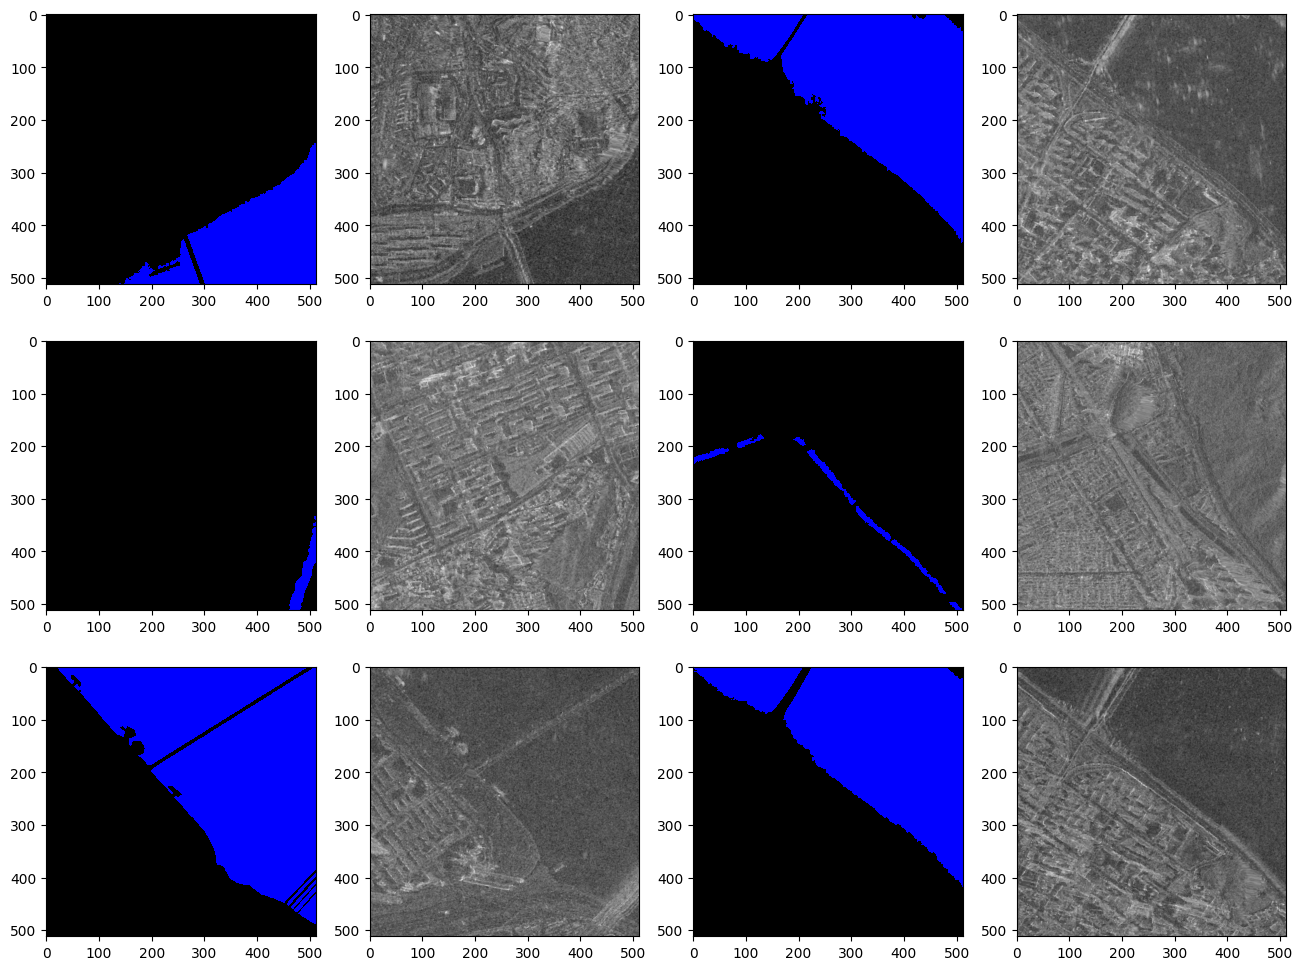

In [10]:
from matplotlib.colors import ListedColormap
cmap = ListedColormap(['black','blue'])
num_rows = 3
num_cols = 2
num_images = num_rows*num_cols
class_names = ['Non-water','Water']

sel_num = np.random.randint(0,np.array(ai_data['TSX']['train']['image']).shape[0]-1,size=num_images)

# with aug
plt.figure(figsize=(4*2*num_cols, 4*num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plt.imshow(ai_data['TSX']['train']['label'][i],cmap=cmap)
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plt.imshow(ai_data['TSX']['train']['image'][i],cmap='gray')

plt.show()



# 3. Writing Datasets

In [11]:
output_path = f"{my_path}/TSX_ai_data.pkl"
with open(output_path, 'wb') as f:
    pickle.dump(ai_data, f)

print(f"AI data has been saved to {output_path}")

AI data has been saved to /workspace/pytorch_unet/python-programs/Tensor/02_IITP/TSX_ai_data.pkl
